In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [14]:
voice_data = pd.read_csv('voice.csv')
voice_data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [15]:
voice_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [16]:
voice_data.isnull().sum()#.sum()

meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64

In [17]:
X = voice_data.drop(['label'], axis = 1)
y = voice_data['label']

In [18]:
# Формируем обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2534, 20)
Test shape: (634, 20)


In [ ]:
# Инициализируем модель дерева решений с максимальной глубиной 1 и обучаем её
dt_voice = tree.DecisionTreeClassifier(max_depth=1, criterion='entropy')
dt_voice.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=1)

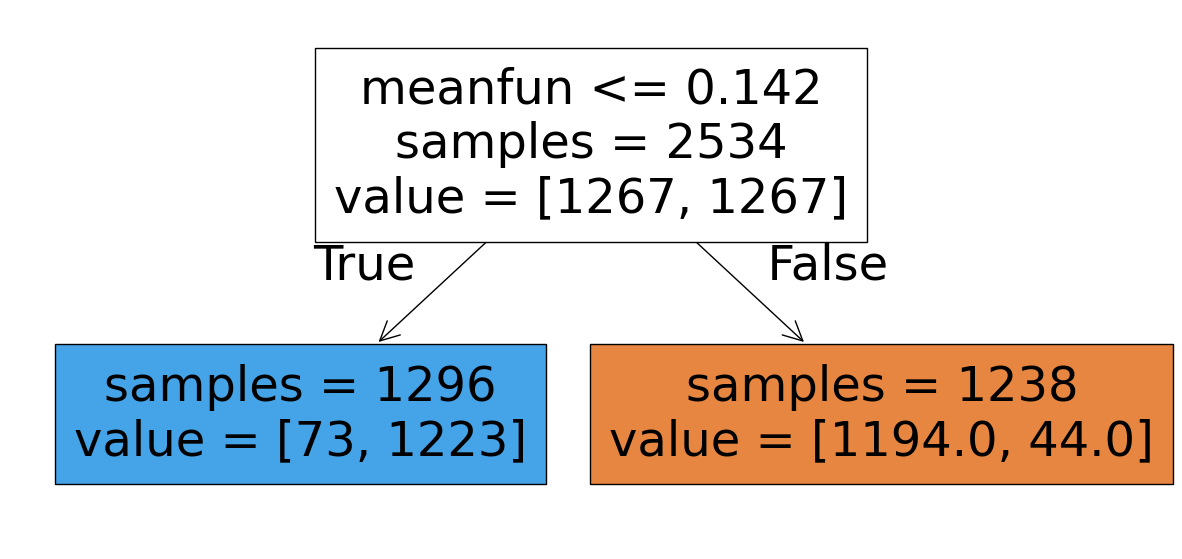

In [21]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_voice, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
);

In [33]:
y_test_pred = dt_voice.predict(X_test)
print(f"Accuracy: {round(metrics.accuracy_score(y_test, y_test_pred),3)}")

Accuracy: 0.956


In [ ]:
# Инициализируем модель дерева решений с максимальной глубиной 2 и обучаем её
dt_voice_2 = tree.DecisionTreeClassifier(max_depth=2, criterion='entropy')
dt_voice_2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

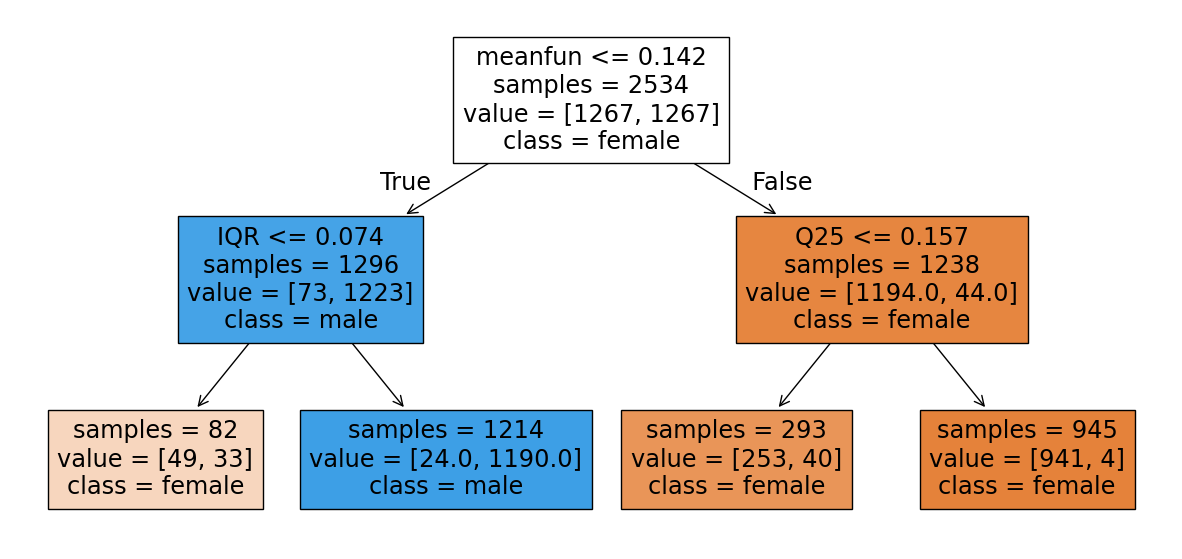

In [37]:
# Визуализируем дерево решений в виде графа
fig = plt.figure(figsize=(15, 7))
tree_graph = tree.plot_tree(
    dt_voice_2, #дерево решений 
    feature_names=list(X.columns), #имена факторов
    filled=True, #расцветка
    impurity=False, #отображать ли неоднородность
    class_names=dt_voice_2.classes_
);

In [38]:
y_test_pred_2 = dt_voice_2.predict(X_test)
print(f"Accuracy: {round(metrics.accuracy_score(y_test, y_test_pred_2),3)}")

Accuracy: 0.962


In [45]:
# Инициализируем модель дерева решений с максимальной глубиной и обучаем её
dt_voice_3 = tree.DecisionTreeClassifier( criterion='entropy', random_state=0)
dt_voice_3.fit(X_train, y_train)
dt_voice_3.get_depth()

12

In [46]:
dt_voice_3.get_n_leaves()

np.int64(54)

In [47]:
y_pred_3_train = dt_voice_3.predict(X_train)
print(f"Accuracy: {round(metrics.accuracy_score(y_train, y_pred_3_train),3)}")

Accuracy: 1.0


In [48]:
y_pred_3_test = dt_voice_3.predict(X_test)
print(f"Accuracy: {round(metrics.accuracy_score(y_test, y_pred_3_test),3)}")

Accuracy: 0.973


In [49]:
# Задаём сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'], #критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], #максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10] #минимальное количество объектов, необходимое для сплита
}

In [50]:
# Задаём метод кросс-валидации
cv = model_selection.StratifiedKFold(n_splits=5)

In [58]:
grid_search = GridSearchCV(
    estimator = tree.DecisionTreeClassifier(
        random_state=0, #генератор случайных чисел
        #max_iter=1000 #количество итераций на сходимость
    ), 
    param_grid=param_grid, 
    cv=cv, 
    n_jobs = -1,
    scoring='accuracy'
)  

In [59]:
%time grid_search.fit(X_train, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_train, y_train)))

CPU times: total: 391 ms
Wall time: 3.3 s
accuracy на тестовом наборе: 1.00


In [60]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}

In [61]:
# Инициализируем модель дерева решений с максимальной глубиной и обучаем её
dt_voice_4 = tree.DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=3, random_state=0)
dt_voice_4.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_split=3, random_state=0)

In [62]:
y_pred_4_train = dt_voice_4.predict(X_train)
print(f"Accuracy: {round(metrics.accuracy_score(y_train, y_pred_4_train),3)}")

Accuracy: 0.996


In [63]:
y_pred_4_test = dt_voice_4.predict(X_test)
print(f"Accuracy: {round(metrics.accuracy_score(y_test, y_pred_4_test),3)}")

Accuracy: 0.97


In [ ]:
dt_voice_4.feature_importances_.

<Axes: >

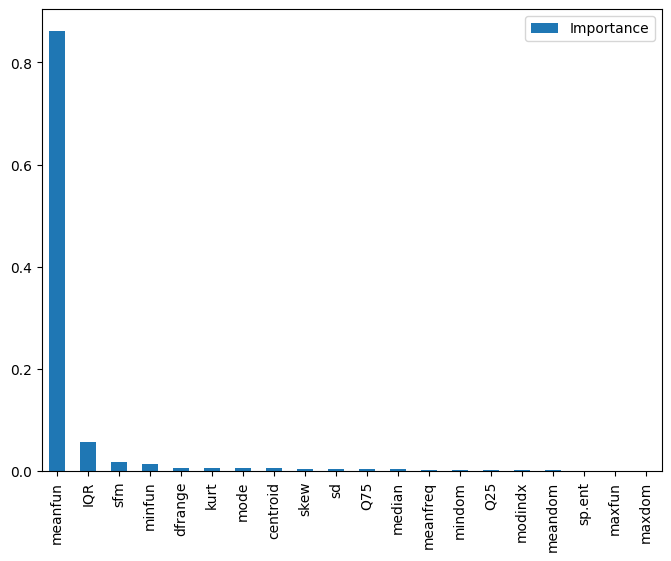

In [ ]:
feat_importances = pd.DataFrame(dt_voice_4.feature_importances_, index=X_train.columns, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
feat_importances.plot(kind='bar', figsize=(8,6))